# Final Project: Cyber Attack Detection Using Machine Learning
> 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Semester 1/2568

**กลุ่ม:** ทำคนเดียว  
- สมาชิกที่ 1: พิชชากร คำพรม (68114540429)

**Dataset:** UNSW-NB15 Version 5  
**Dataset source:** https://www.kaggle.com/datasets/dhoogla/unswnb15  
The Version 5 release contains `UNSW_NB15_training-set.parquet` and `UNSW_NB15_testing-set.parquet`.

**Research Question:**  
Can machine learning models accurately distinguish normal network traffic from cyber attacks using the UNSW-NB15 dataset?

**Problem Statement:**  
โครงงานนี้ศึกษาการจำแนก network traffic ว่าเป็น normal traffic หรือ cyber attack โดยใช้ข้อมูล UNSW-NB15 และเปรียบเทียบประสิทธิภาพของ Logistic Regression, KNN และ Random Forest ข้อมูลนี้เหมาะกับปัญหาดังกล่าวเพราะมี network traffic features หลายรูปแบบและมี target `label` ที่ระบุว่า traffic เป็น normal หรือ attack ทำให้สามารถประยุกต์ใช้ทั้ง PCA, statistical learning, classification และ cross-validation ได้อย่างเป็นระบบ

---

| CLO | ส่วนที่ครอบคลุม | Status |
|-----|----------------|--------|
| CLO1 (Linear Algebra) | Part 2 | ✓ |
| CLO2 (Statistical Learning) | Part 3 | ✓ |
| CLO3 (Regression/Classification) | Part 4 | ✓ |
| CLO4 (Model Selection) | Part 5 | ✓ |


In [1]:
# ─── Import libraries ──────────────────────────────────────────────
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
print("Ready.")


Ready.


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

In [5]:
import pandas as pd
import numpy as np

In [6]:
# ─── Load UNSW-NB15 Version 5 ────────────────────────────────────
# The dataset files are stored in the public GitHub repository so that
# a fresh Colab session can run without Kaggle authentication.

from pathlib import Path
import urllib.request

DATA_DIR = Path("/content/unsw_nb15_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

train_name = "UNSW_NB15_training-set.parquet"
test_name = "UNSW_NB15_testing-set.parquet"

# Public raw-GitHub URLs. No Kaggle API token is required.
BASE_URL = (
    "https://raw.githubusercontent.com/"
    "pitchakornofficial-prog/Cyber-Attack-Detection-UNSW-NB15/main/"
)

train_path = DATA_DIR / train_name
test_path = DATA_DIR / test_name

def download_if_missing(url, path):
    if not path.exists():
        print(f"Downloading {path.name} ...")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"Using cached file: {path.name}")

download_if_missing(BASE_URL + train_name, train_path)
download_if_missing(BASE_URL + test_name, test_path)

TRAIN_PATH = str(train_path)
TEST_PATH = str(test_path)

print("Training file:", TRAIN_PATH)
print("Testing file:", TEST_PATH)

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)


Training shape: (175341, 36)
Testing shape: (82332, 36)


In [7]:
print(train_df.columns.tolist())

['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


In [8]:
print(train_df.dtypes)

dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd         int8
is_sm_ips_

In [9]:
print(train_df["label"].value_counts())

label
1    119341
0     56000
Name: count, dtype: int64


In [10]:
print(train_df["attack_cat"].value_counts())

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


=== Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
dur,175341.0,1.359389e+00,6.483313e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540618e+04,1.654177e+05,0.0,32.786140,3225.806641,1.250000e+05,1.000000e+06
sload,175341.0,7.345403e+07,1.883701e+08,0.0,13053.338867,879674.750000,8.888889e+07,5.988000e+09
dload,175341.0,6.712055e+05,2.423637e+06,0.0,0.000000,1447.022705,2.784487e+04,2.242273e+07
sloss,175341.0,4.953000e+00,6.600506e+01,0.0,0.000000,0.000000,3.000000e+00,4.803000e+03
dloss,175341.0,6.948010e+00,5.273300e+01,0.0,0.000000,0.000000,2.000000e+00,5.484000e+03



=== Target Distribution ===
label
1    119341
0     56000
Name: count, dtype: int64


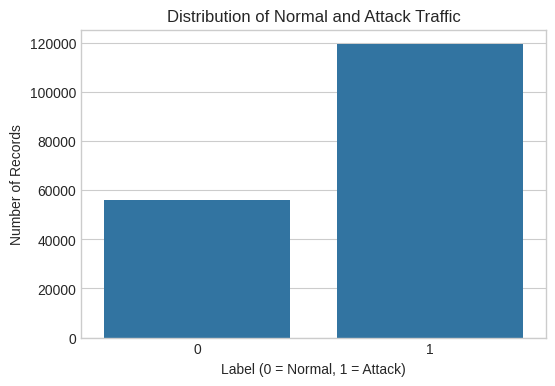

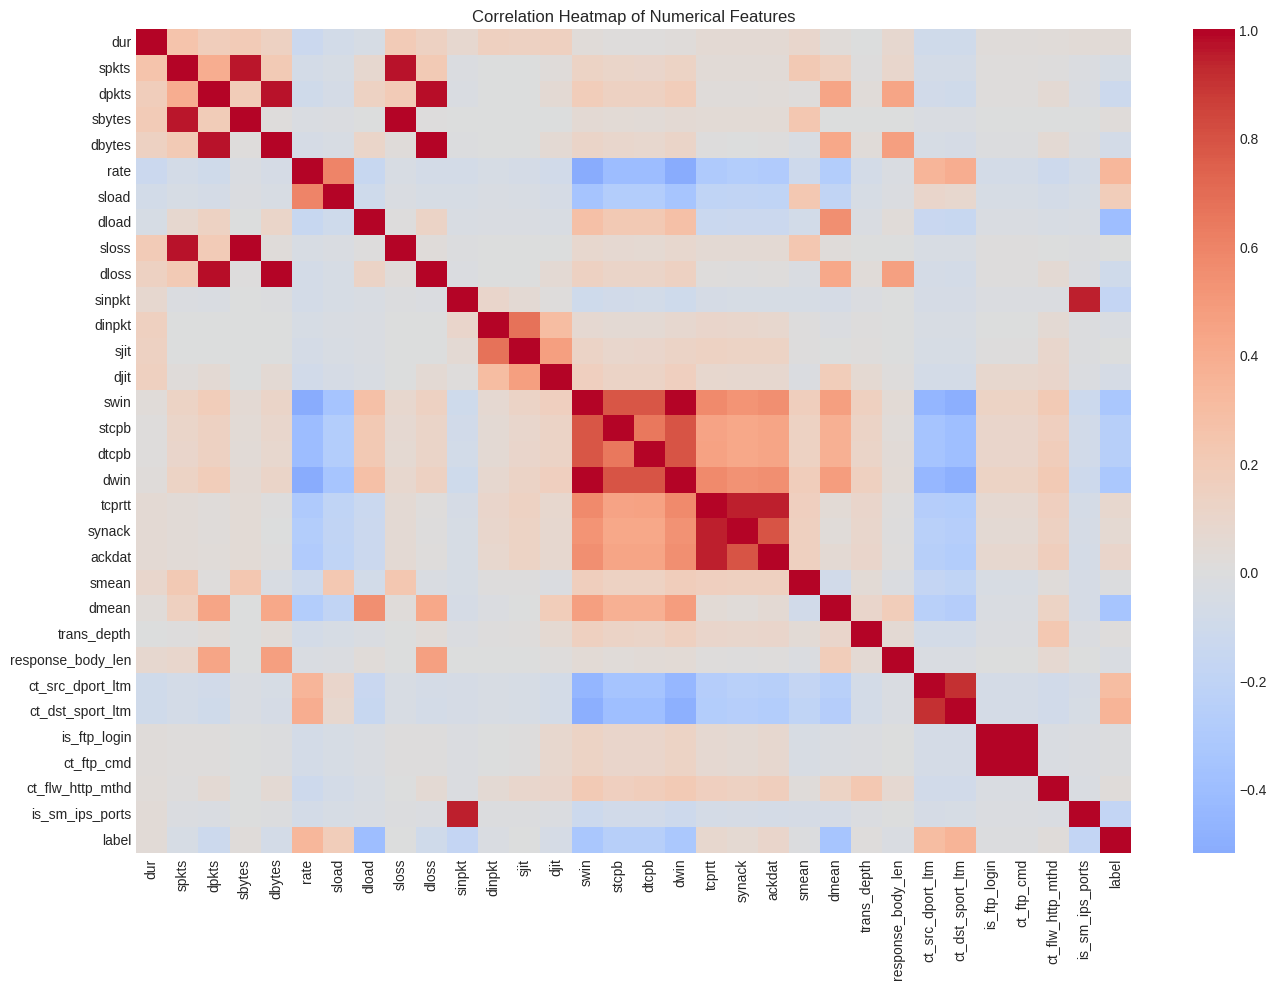

In [11]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูล

import matplotlib.pyplot as plt
import seaborn as sns

# ใช้ Training Set สำหรับ Exploratory Data Analysis
df = train_df.copy()

# ---------------------------------------------------------------
# 1. Summary Statistics
# ---------------------------------------------------------------
print("=== Missing Values ===")
print(df.isnull().sum().sum())

# ---------------------------------------------------------------
# Summary Statistics
# ---------------------------------------------------------------
print("=== Summary Statistics ===")
display(df.describe().T)

# ---------------------------------------------------------------
# 2. Distribution of Target Variable
# ---------------------------------------------------------------
print("\n=== Target Distribution ===")
print(df["label"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Distribution of Normal and Attack Traffic")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Number of Records")
plt.show()

# ---------------------------------------------------------------
# 3. Correlation Heatmap
# ---------------------------------------------------------------
# เลือกเฉพาะ numerical features
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Interpretation

- The summary statistics provide an overview of the numerical features in the UNSW-NB15 training dataset.
- The target distribution shows the proportion of normal and attack traffic.
- The correlation heatmap helps identify relationships among numerical network traffic features.
- Features with strong correlations may contain overlapping information and are relevant when considering dimensionality reduction using PCA.

---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้ใช้ Principal Component Analysis (PCA) เพื่อวิเคราะห์โครงสร้างของ feature space และลดมิติของข้อมูล

**Task ที่เลือก:**  
- **Task A — PCA:** ลด dimension ของ numerical features + Scree Plot + Cumulative Explained Variance + 2D visualization

**เหตุผลที่เลือก:**  
PCA เหมาะกับ dataset นี้เพราะมี numerical features หลายตัวที่มี scale แตกต่างกันและอาจมีความสัมพันธ์กัน PCA ช่วยสรุปทิศทางของความแปรปรวนใน feature space และช่วยตรวจสอบว่าข้อมูลสามารถลดมิติได้มากน้อยเพียงใดโดยยังคงข้อมูลส่วนสำคัญไว้


In [12]:
# ─── CLO1: Linear Algebra Analysis ───────────────────────────────
# เตรียมข้อมูลสำหรับ PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ใช้ Training Set สำหรับ PCA
pca_df = train_df.copy()

# แยก target ออกจาก features
X = pca_df.drop(columns=["label", "attack_cat"], errors="ignore")
y = pca_df["label"]

# เลือกเฉพาะ numerical features
X_numeric = X.select_dtypes(include=np.number)

print("Original feature shape:", X.shape)
print("Numerical feature shape:", X_numeric.shape)

# ตรวจสอบ missing values
print("\nMissing values:")
print(X_numeric.isnull().sum().sum())

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

print("\nScaled data shape:", X_scaled.shape)
print("Mean of first 5 features:", X_scaled.mean(axis=0)[:5])
print("Std of first 5 features:", X_scaled.std(axis=0)[:5])

Original feature shape: (175341, 34)
Numerical feature shape: (175341, 31)

Missing values:
0

Scaled data shape: (175341, 31)
Mean of first 5 features: [-5.41393681e-17 -1.42642647e-17  5.18700533e-18 -1.05361046e-18
  1.41021707e-17]
Std of first 5 features: [1. 1. 1. 1. 1.]


In [13]:
# ─── PCA Analysis ────────────────────────────────────────────────

# Fit PCA โดยเก็บทุก Principal Component
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Number of original features:", X_scaled.shape[1])
print("Number of principal components:", X_pca.shape[1])

print("\nExplained variance ratio:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f} ({variance*100:.2f}%)")

Number of original features: 31
Number of principal components: 31

Explained variance ratio:
PC1: 0.2075 (20.75%)
PC2: 0.1173 (11.73%)
PC3: 0.0939 (9.39%)
PC4: 0.0684 (6.84%)
PC5: 0.0668 (6.68%)
PC6: 0.0644 (6.44%)
PC7: 0.0590 (5.90%)
PC8: 0.0473 (4.73%)
PC9: 0.0377 (3.77%)
PC10: 0.0354 (3.54%)
PC11: 0.0275 (2.75%)
PC12: 0.0256 (2.56%)
PC13: 0.0248 (2.48%)
PC14: 0.0233 (2.33%)
PC15: 0.0223 (2.23%)
PC16: 0.0196 (1.96%)
PC17: 0.0113 (1.13%)
PC18: 0.0108 (1.08%)
PC19: 0.0093 (0.93%)
PC20: 0.0087 (0.87%)
PC21: 0.0068 (0.68%)
PC22: 0.0066 (0.66%)
PC23: 0.0029 (0.29%)
PC24: 0.0017 (0.17%)
PC25: 0.0004 (0.04%)
PC26: 0.0003 (0.03%)
PC27: 0.0002 (0.02%)
PC28: 0.0001 (0.01%)
PC29: 0.0000 (0.00%)
PC30: 0.0000 (0.00%)
PC31: 0.0000 (0.00%)


In [ ]:
# ─── PCA Loading Analysis ─────────────────────────────────────────

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_numeric.columns,
    columns=[f"PC{i}" for i in range(1, len(pca.components_) + 1)]
)

pc1_top = (
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 features contributing to PC1:")
display(pc1_top.to_frame("Absolute Loading"))

print(
    f"PC1 explained variance: "
    f"{pca.explained_variance_ratio_[0] * 100:.2f}%"
)


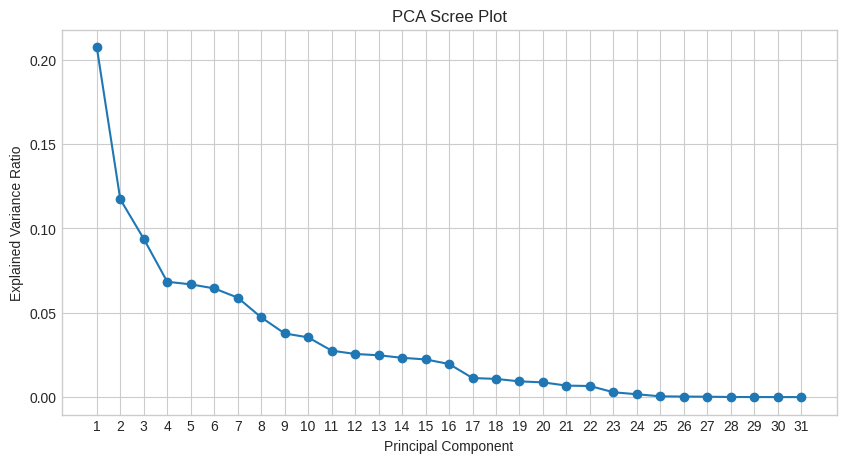

In [14]:
# ─── Scree Plot ─────────────────────────────────────────────────

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)
plt.show()

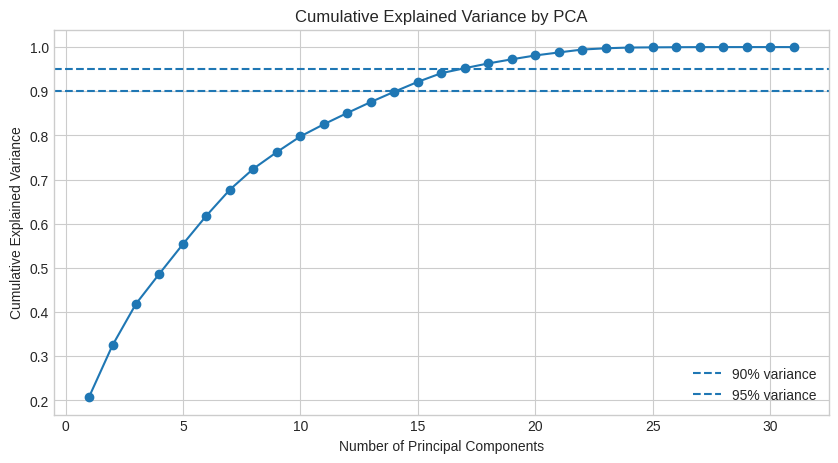

Components needed for 90% variance: 15
Components needed for 95% variance: 17


In [15]:
# ─── Cumulative Explained Variance ───────────────────────────────

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% variance"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA")
plt.legend()
plt.grid(True)
plt.show()

# จำนวน components ที่อธิบาย variance ได้อย่างน้อย 90% และ 95%
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Components needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")

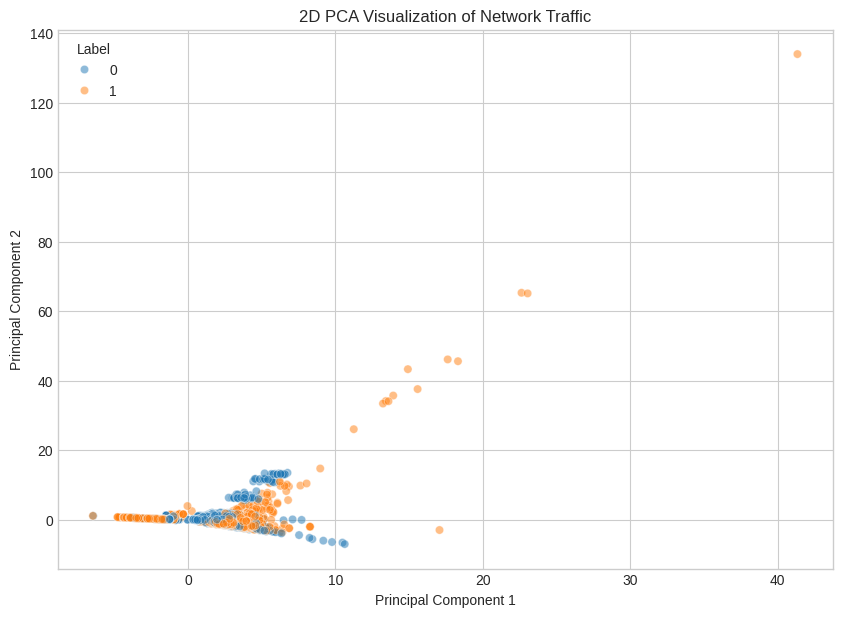

PC1 explained variance: 20.75%
PC2 explained variance: 11.73%
Total variance explained by PC1 + PC2: 32.48%


In [16]:
# ─── 2D PCA Visualization ───────────────────────────────────────

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "label": y.values
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_plot_df.sample(
        n=min(10000, len(pca_plot_df)),
        random_state=42
    ),
    x="PC1",
    y="PC2",
    hue="label",
    alpha=0.5
)

plt.title("2D PCA Visualization of Network Traffic")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Label")
plt.show()

print("PC1 explained variance:",
      f"{pca_2d.explained_variance_ratio_[0]*100:.2f}%")

print("PC2 explained variance:",
      f"{pca_2d.explained_variance_ratio_[1]*100:.2f}%")

print("Total variance explained by PC1 + PC2:",
      f"{pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

### Interpretation

PCA was applied to the standardized numerical features of the UNSW-NB15 training dataset. Standardization was performed before PCA so that features with different scales would contribute more appropriately to the principal components.

The scree plot shows how much variance is explained by each principal component. The cumulative explained variance indicates how many principal components are required to retain approximately 90% and 95% of the total variance.

The 2D PCA visualization projects the network traffic data onto the first two principal components. The separation or overlap between normal and attack traffic provides an initial visual indication of whether the original numerical features contain patterns that can distinguish the two classes.

These PCA results are useful for understanding the structure and dimensionality of the network traffic data before applying machine learning models.


### Insight จาก CLO1 Analysis

PCA was applied to the 31 standardized numerical features of the UNSW-NB15 training dataset. **PC1 explains 20.75% of the total variance**, while **PC2 explains 11.73%**. Therefore, **PC1 and PC2 together explain 32.48%** of the total variance.

The cumulative explained variance increases as more principal components are included. This shows that the information in the original 31-dimensional feature space is distributed across multiple principal components rather than being concentrated in only the first two components.

PCA loading values can be used to identify which numerical features contribute most strongly to each principal component. Features with larger absolute loading values have a stronger contribution to the corresponding component.

The 2D PCA visualization provides an initial view of the relationship between normal and attack traffic. Because PC1 and PC2 explain only 32.48% of the total variance, overlap between the two classes in the 2D plot should not be interpreted as evidence that the full feature space cannot distinguish the classes. This supports using supervised classification models in the later stages of the project.


---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
- แสดง distribution ของ features สำคัญ (histogram/boxplot)
- Identify features ที่ correlate กับ target มากที่สุด
- อธิบาย bias-variance trade-off สำหรับ Classification
- แสดง Train/Validation Accuracy สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม:** dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?

In [17]:
# ─── CLO2: Statistical Learning ─────────────────────────────────
# Distribution Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# ใช้ Training Set
stats_df = train_df.copy()

# เลือก numerical features
numeric_features = stats_df.select_dtypes(include=np.number).columns.tolist()

# ไม่รวม target
numeric_features = [
    col for col in numeric_features
    if col != "label"
]

print("Number of numerical features:", len(numeric_features))
print("Numerical features:")
print(numeric_features)

Number of numerical features: 31
Numerical features:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']


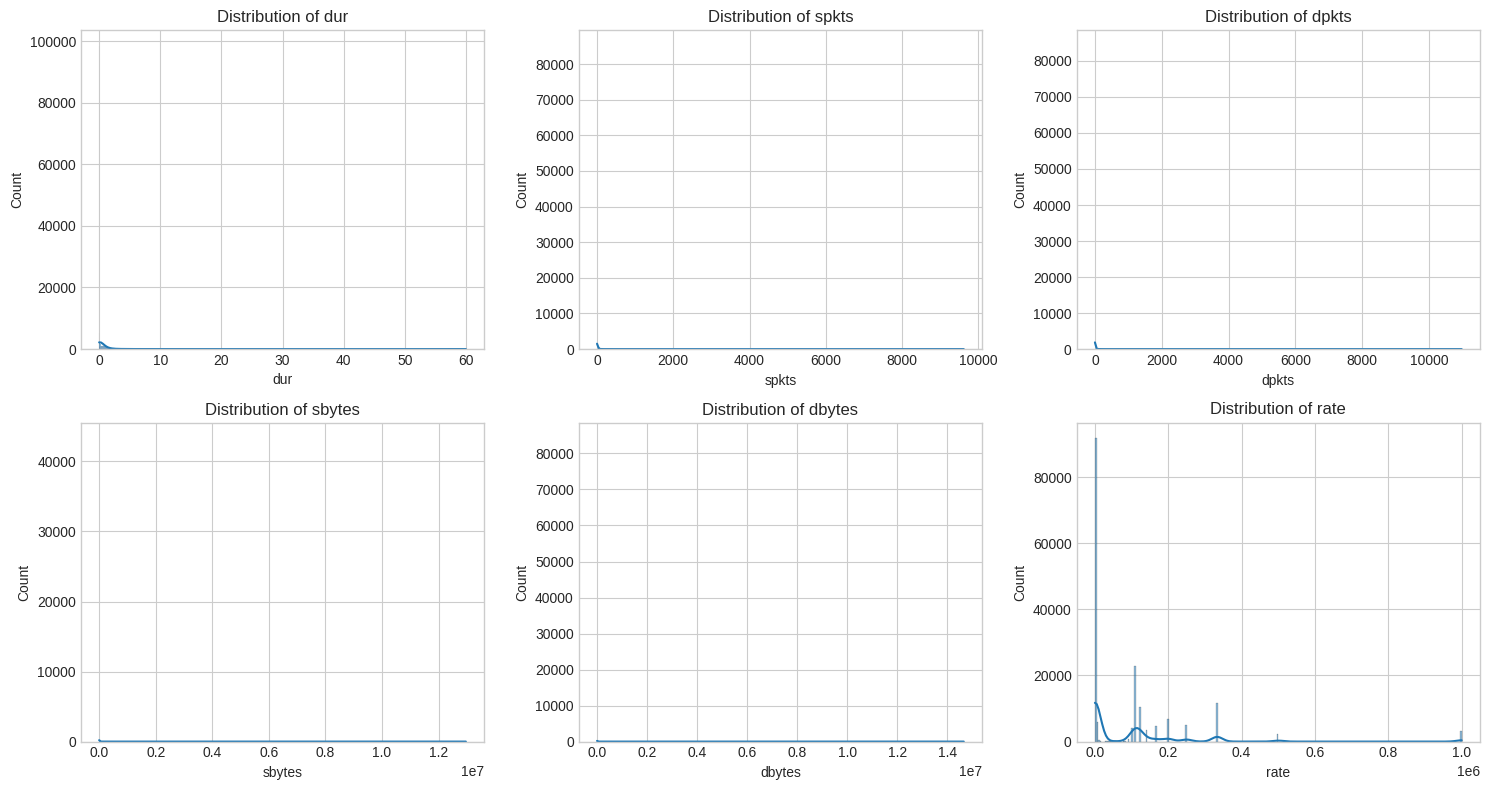

In [18]:
# ─── Distribution of Selected Features ───────────────────────────

# เลือก features ที่มีประโยชน์สำหรับ visualization
selected_features = numeric_features[:6]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8)
)

for ax, feature in zip(axes.flatten(), selected_features):
    sns.histplot(
        data=stats_df,
        x=feature,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

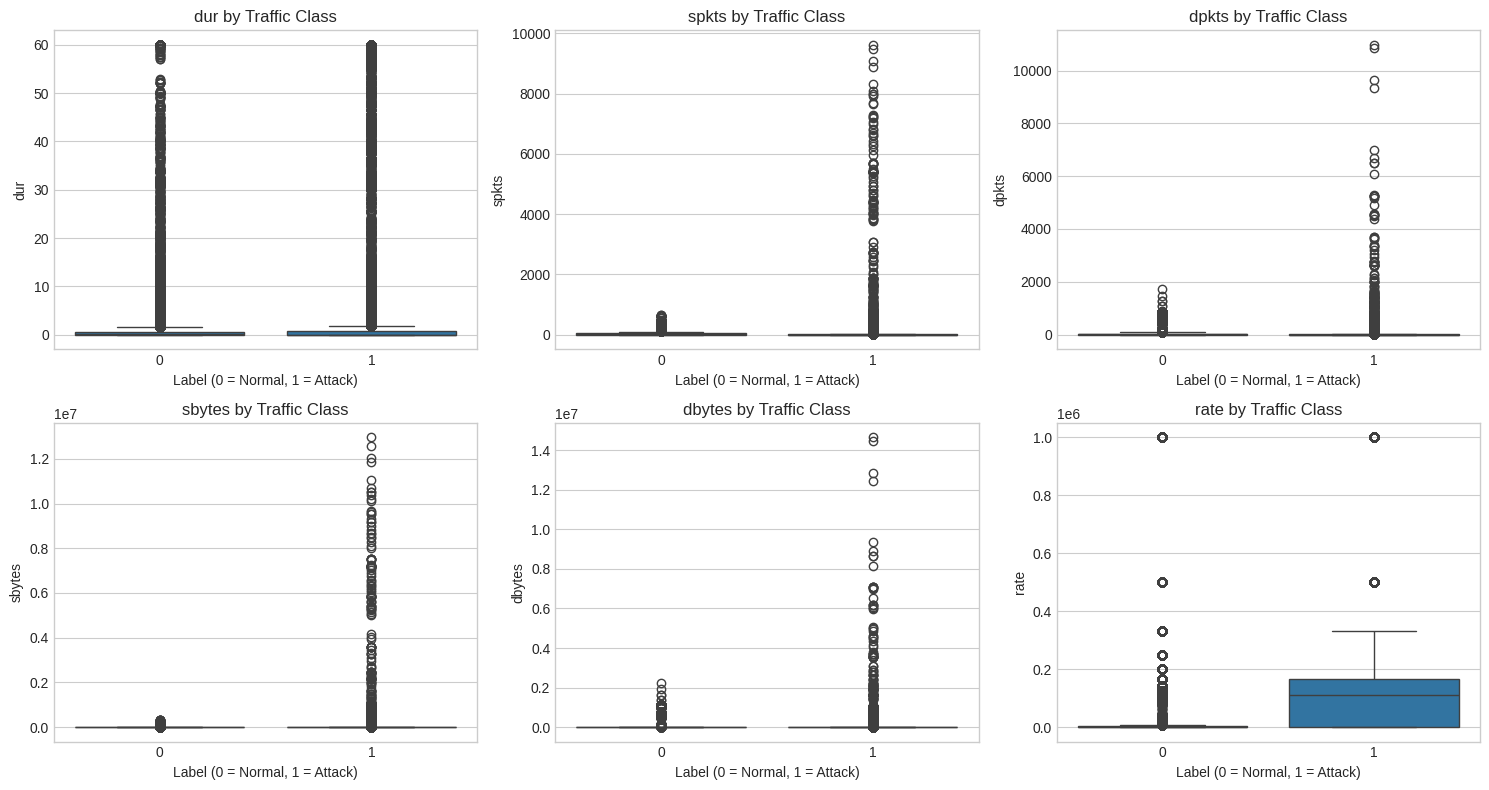

In [19]:
# ─── Feature Distribution by Target Class ─────────────────────────

selected_features = numeric_features[:6]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8)
)

for ax, feature in zip(axes.flatten(), selected_features):
    sns.boxplot(
        data=stats_df,
        x="label",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Traffic Class")
    ax.set_xlabel("Label (0 = Normal, 1 = Attack)")

plt.tight_layout()
plt.show()

In [20]:
# ─── Group Statistics ────────────────────────────────────────────

group_stats = stats_df.groupby("label")[numeric_features].mean().T

group_stats.columns = [
    "Normal (0)",
    "Attack (1)"
]

display(group_stats)

,Normal (0),Attack (1)
dur,1.017177e+00,1.519969e+00
spkts,3.072548e+01,1.540595e+01
dpkts,3.805770e+01,1.001262e+01
sbytes,4.105703e+03,1.106866e+04
dbytes,3.104946e+04,7.364456e+03
rate,1.379931e+04,1.336997e+05
sload,2.317070e+07,9.704917e+07
dload,2.062949e+06,1.813877e+04
sloss,5.014679e+00,4.924058e+00
dloss,1.423693e+01,3.527731e+00


In [21]:
# ─── Correlation with Target ─────────────────────────────────────

correlation_with_target = (
    stats_df[numeric_features + ["label"]]
    .corr()["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

print("Correlation of numerical features with target:")
display(correlation_with_target.to_frame("Correlation with Label"))

Correlation of numerical features with target:


,Correlation with Label
dload,-0.393739
ct_dst_sport_ltm,0.357213
dmean,-0.341806
rate,0.337979
swin,-0.333633
dwin,-0.319626
ct_src_dport_ltm,0.305579
stcpb,-0.255006
dtcpb,-0.250340
is_sm_ips_ports,-0.184679


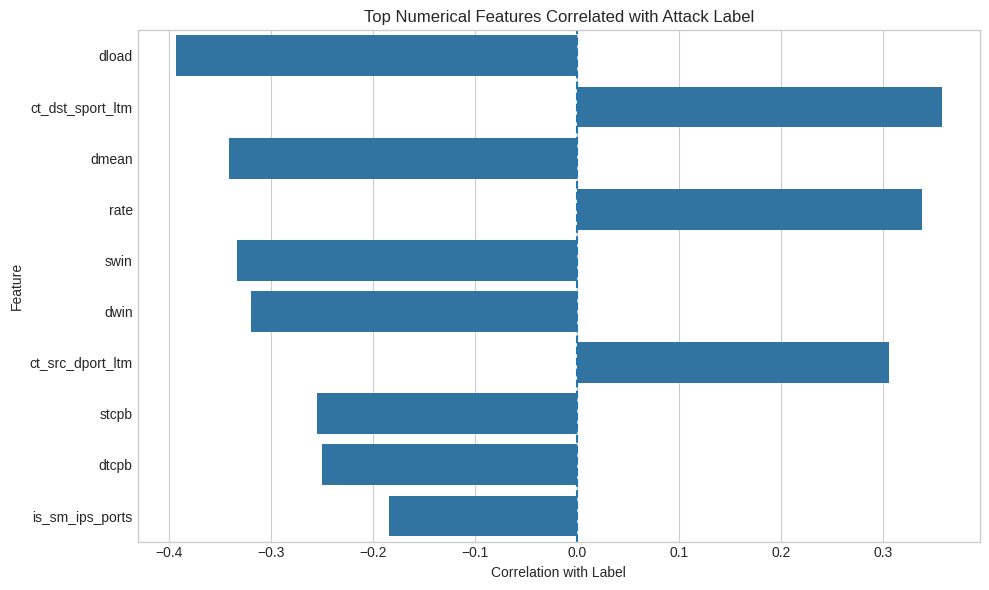

In [22]:
# ─── Top Feature Correlations with Target ─────────────────────────

top_n = min(10, len(correlation_with_target))

top_correlations = correlation_with_target.head(top_n)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)

plt.axvline(0, linestyle="--")
plt.xlabel("Correlation with Label")
plt.ylabel("Feature")
plt.title("Top Numerical Features Correlated with Attack Label")

plt.tight_layout()
plt.show()

In [23]:
# ─── Bias-Variance Analysis using KNN ────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# ใช้ sample เพื่อให้การทดลองทำงานเร็วขึ้น
sample_size = min(30000, len(X_numeric))

rng = np.random.RandomState(42)
sample_indices = rng.choice(
    len(X_numeric),
    size=sample_size,
    replace=False
)

# ใช้ raw numerical features ก่อน scaling
X_bv_raw = X_numeric.iloc[sample_indices].copy()
y_sample = y.iloc[sample_indices].values

# แบ่ง train / validation ก่อน เพื่อป้องกันข้อมูล validation
# ถูกใช้ในการ fit scaler
X_train_bv_raw, X_val_bv_raw, y_train_bv, y_val_bv = train_test_split(
    X_bv_raw,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

scaler_bv = StandardScaler()
X_train_bv = scaler_bv.fit_transform(X_train_bv_raw)
X_val_bv = scaler_bv.transform(X_val_bv_raw)

k_values = [1, 3, 5, 7, 11, 15, 21, 31]

train_scores = []
val_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bv, y_train_bv)

    train_pred = knn.predict(X_train_bv)
    val_pred = knn.predict(X_val_bv)

    train_scores.append(
        accuracy_score(y_train_bv, train_pred)
    )

    val_scores.append(
        accuracy_score(y_val_bv, val_pred)
    )

print("Bias-Variance analysis completed.")


Bias-Variance analysis completed.


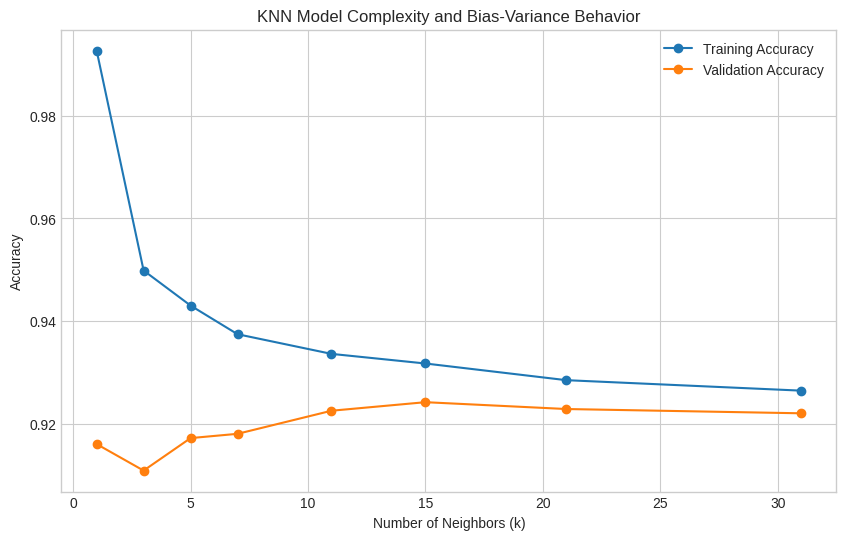

In [24]:
# ─── Bias-Variance / Model Complexity Plot ───────────────────────

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    k_values,
    val_scores,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Model Complexity and Bias-Variance Behavior")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
# ─── KNN Performance Table ───────────────────────────────────────

bv_results = pd.DataFrame({
    "k": k_values,
    "Training Accuracy": train_scores,
    "Validation Accuracy": val_scores
})

display(bv_results)

,k,Training Accuracy,Validation Accuracy
0,1,0.992708,0.916000
1,3,0.949833,0.910833
2,5,0.943000,0.917167
3,7,0.937417,0.918000
4,11,0.933583,0.922500
5,15,0.931708,0.924167
6,21,0.928458,0.922833
7,31,0.926417,0.922000


### Interpretation

The statistical analysis provides an overview of the distributions and relationships among numerical network traffic features in the UNSW-NB15 dataset.

The feature distributions show that network traffic variables can have different ranges and shapes. Therefore, feature scaling is important before applying distance-based models such as KNN and dimensionality reduction methods such as PCA.

The boxplots and group statistics compare numerical features between normal traffic and attack traffic. Differences in the distributions between the two classes suggest that some network traffic characteristics may provide useful information for classification.

The correlation analysis measures the linear relationship between numerical features and the binary attack label. Features with larger absolute correlations may contain more information about the target, although correlation alone does not imply causation or guarantee strong predictive performance.

The KNN bias-variance analysis demonstrates the effect of model complexity through different values of k. A very small k can produce high training performance but may be sensitive to individual observations, indicating a higher risk of overfitting. Increasing k makes the model smoother and generally increases bias while reducing variance.

The results from this analysis will be used to guide the machine learning model selection and evaluation in the following sections.


### Insight จาก CLO2 Analysis

The statistical analysis shows clear differences in the distributions and group means of several numerical network traffic features between normal and attack traffic. The strongest absolute linear correlations with the attack label were observed for `dload` (-0.3937), `ct_dst_sport_ltm` (0.3572), `dmean` (-0.3418), `rate` (0.3380), and `swin` (-0.3336). These correlations indicate association with the target, but they do not by themselves imply causation or guarantee predictive performance.

The target variable is binary, with 119,341 attack records and 56,000 normal records in the training set. Because the classes are not perfectly balanced, evaluation should consider precision, recall, and F1-score in addition to accuracy.

The KNN bias-variance analysis also demonstrates the effect of model complexity. At `k=1`, training accuracy is very high (0.9927) while validation accuracy is 0.9160, indicating a large generalization gap and sensitivity to individual observations. Validation accuracy improves as `k` increases and reaches its highest observed value of **0.9242 at `k=15`** in this experiment, while training accuracy decreases to 0.9317. This illustrates the bias-variance trade-off: very small `k` can have high variance, while excessively large `k` can increase bias.

These results provide a statistical basis for the later model comparison and support using a moderate KNN neighborhood size rather than an extremely small value.


---
## Part 4: CLO3 — Model Building

ในส่วนนี้สร้าง Classification models เพื่อจำแนก network traffic เป็น Normal หรือ Attack

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Precision, Recall, F1-score และ Confusion Matrix

**Dataset ของโครงงาน:** ☑ Classification  ☐ Regression


In [26]:
# ─── CLO3: Model Building ────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ใช้ Training Set เท่านั้นสำหรับการสร้างและประเมินโมเดล
model_df = train_df.copy()

# แยก target
y_model = model_df["label"]

# เลือก numerical features
X_model = model_df.drop(
    columns=["label", "attack_cat"],
    errors="ignore"
)

X_model = X_model.select_dtypes(include=np.number)

print("Feature shape:", X_model.shape)
print("Target shape:", y_model.shape)

print("\nTarget distribution:")
print(y_model.value_counts())

Feature shape: (175341, 31)
Target shape: (175341,)

Target distribution:
label
1    119341
0     56000
Name: count, dtype: int64


In [27]:
# ─── Train / Validation Split ────────────────────────────────────

X_train, X_val, y_train, y_val = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 140272
Validation samples: 35069


In [28]:
# ─── Feature Scaling ─────────────────────────────────────────────

scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(X_train)
X_val_scaled = scaler_model.transform(X_val)

print("Training scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)

Training scaled shape: (140272, 31)
Validation scaled shape: (35069, 31)


In [29]:
# ─── Model 1: Logistic Regression ────────────────────────────────

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(X_val_scaled)

print("=== Logistic Regression ===")
print(
    classification_report(
        y_val,
        logistic_pred,
        target_names=["Normal", "Attack"]
    )
)

=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       0.94      0.73      0.82     11200
      Attack       0.88      0.98      0.93     23869

    accuracy                           0.90     35069
   macro avg       0.91      0.85      0.87     35069
weighted avg       0.90      0.90      0.89     35069



In [30]:
# ─── Model 2: K-Nearest Neighbors ────────────────────────────────

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

knn_pred = knn_model.predict(X_val_scaled)

print("=== K-Nearest Neighbors ===")
print(
    classification_report(
        y_val,
        knn_pred,
        target_names=["Normal", "Attack"]
    )
)

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

      Normal       0.91      0.85      0.88     11200
      Attack       0.93      0.96      0.95     23869

    accuracy                           0.93     35069
   macro avg       0.92      0.91      0.91     35069
weighted avg       0.93      0.93      0.93     35069



In [31]:
# ─── Model Performance Comparison ────────────────────────────────

model_results = []

models_predictions = {
    "Logistic Regression": logistic_pred,
    "KNN": knn_pred
}

for model_name, predictions in models_predictions.items():

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, predictions),
        "Precision": precision_score(y_val, predictions),
        "Recall": recall_score(y_val, predictions),
        "F1 Score": f1_score(y_val, predictions)
    })

model_results_df = pd.DataFrame(model_results)

display(
    model_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8985,0.8843,0.9790,0.9293
1,KNN,0.9270,0.9323,0.9626,0.9472


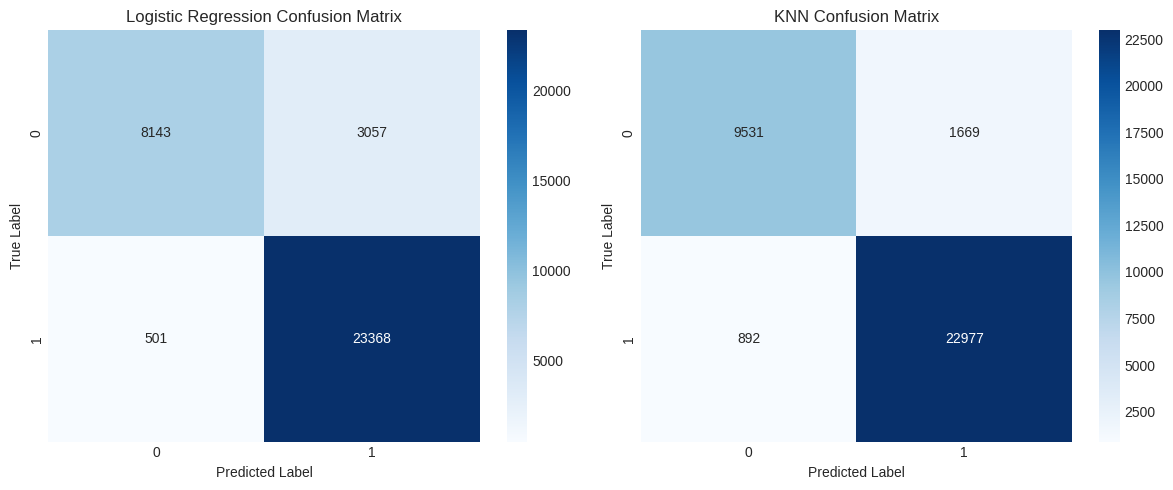

In [32]:
# ─── Confusion Matrices ──────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

model_predictions = [
    ("Logistic Regression", logistic_pred),
    ("KNN", knn_pred)
]

for ax, (model_name, predictions) in zip(
    axes,
    model_predictions
):

    cm = confusion_matrix(
        y_val,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

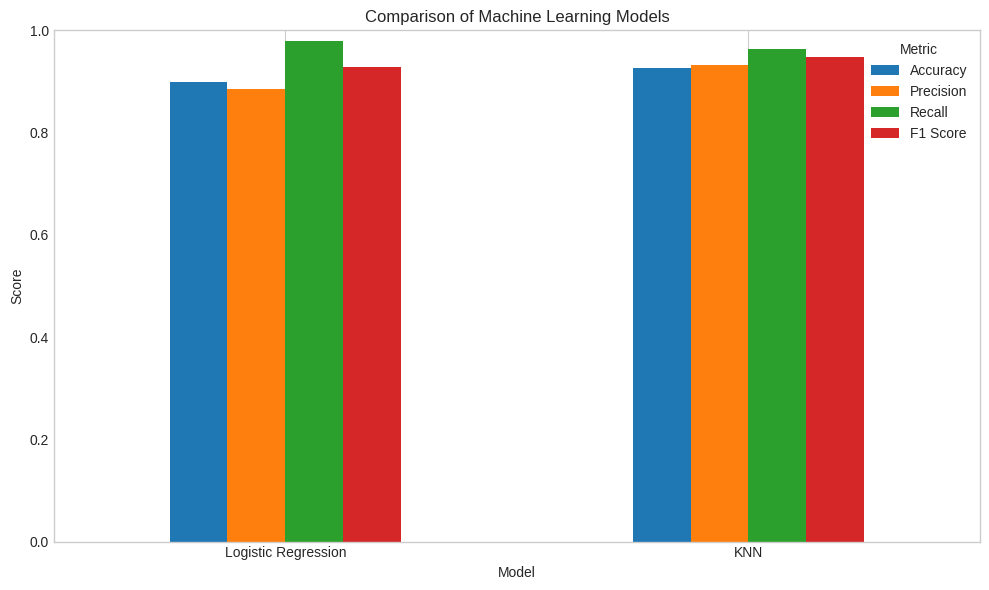

In [33]:
# ─── Model Metric Comparison ─────────────────────────────────────

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

plot_df = model_results_df.set_index("Model")[metrics]

plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Interpretation

Two classification models, Logistic Regression and K-Nearest Neighbors (KNN), were developed to distinguish normal network traffic from cyber attack traffic.

The dataset was divided into training and validation sets using stratified sampling to preserve the proportion of the two target classes. Numerical features were standardized using parameters learned only from the training data to avoid data leakage.

Logistic Regression provides a linear decision boundary and serves as a baseline classification model. KNN is a distance-based model that can capture more local patterns in the feature space.

The models were evaluated using accuracy, precision, recall, and F1-score. The confusion matrices provide additional information about correct and incorrect predictions for normal and attack traffic.

The comparison of these metrics shows how the two models perform under the same validation setting. In particular, recall is important for attack detection because it measures the proportion of actual attack traffic that is correctly identified.

The results provide a basis for comparing these models with additional models and cross-validation experiments in CLO4.


## สรุป Model Comparison

| Model               | Train Metric (F1) | Validation Metric (F1) | รายละเอียด                                                                                        |
| ------------------- | ----------------: | --------------------------: | ------------------------------------------------------------------------------------------------- |
| Logistic Regression |            0.9340 |                      0.9293 | Linear classification model; performance is relatively consistent between training and validation |
| KNN                 |            0.9612 |                      0.9472 | Distance-based model; captures local patterns but has a larger train-validation gap               |
| Random Forest       |                 — | 0.9648 ± 0.0008 (5-Fold CV) | Tree-based ensemble model; achieved the highest mean F1-score in 5-Fold Cross-Validation          |

### Insight

The three models show different learning characteristics. Logistic Regression has a relatively small difference between training and validation F1-score, suggesting that its performance is comparatively stable but its linear decision boundary may limit its ability to capture more complex patterns.

KNN achieves a higher validation F1-score than Logistic Regression, but the difference between its training and validation performance is larger. This indicates a greater sensitivity to the training data and a potential tendency toward overfitting compared with Logistic Regression.

Random Forest achieved the highest mean F1-score in the 5-Fold Cross-Validation experiment, with a mean F1-score of approximately 0.9648 and a standard deviation of 0.0008 across the five folds. The small standard deviation indicates consistent performance across the folds.

Overall, the cross-validation results show that the three models have different performance and stability characteristics. The results support further evaluation of Random Forest on the held-out testing dataset before making a final assessment of its generalization performance.


---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
- เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
- Plot bar chart ของ CV MSE (หรือ Accuracy สำหรับ Classification)
- สรุปว่า model ไหนดีที่สุดและทำไม

In [34]:
# ─── CLO4: Model Selection ───────────────────────────────────────

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer

In [35]:
# ─── Define Models ───────────────────────────────────────────────

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

print("Models:")
for name in models:
    print("-", name)

Models:
- Logistic Regression
- KNN
- Random Forest


In [36]:
# ─── 5-Fold Cross-Validation ─────────────────────────────────────

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = {}

for model_name, model in models.items():

    print(f"Running 5-Fold CV: {model_name}")

    scores = cross_validate(
        model,
        X_model,
        y_model,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results[model_name] = scores

print("\nCross-validation completed.")

Running 5-Fold CV: Logistic Regression
Running 5-Fold CV: KNN
Running 5-Fold CV: Random Forest

Cross-validation completed.


In [37]:
# ─── Cross-Validation Results ────────────────────────────────────

cv_summary = []

for model_name, scores in cv_results.items():

    cv_summary.append({
        "Model": model_name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })

cv_summary_df = pd.DataFrame(cv_summary)

display(
    cv_summary_df.style.format({
        "Accuracy Mean": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "Precision Mean": "{:.4f}",
        "Precision Std": "{:.4f}",
        "Recall Mean": "{:.4f}",
        "Recall Std": "{:.4f}",
        "F1 Mean": "{:.4f}",
        "F1 Std": "{:.4f}"
    })
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,Logistic Regression,0.9044,0.0013,0.8910,0.0012,0.9793,0.0007,0.9331,0.0009
1,KNN,0.9186,0.0035,0.9364,0.0011,0.9445,0.0049,0.9404,0.0027
2,Random Forest,0.9516,0.0011,0.9542,0.0006,0.9757,0.0012,0.9648,0.0008


In [38]:
# ─── Fold-by-Fold F1 Scores ──────────────────────────────────────

fold_f1_data = []

for model_name, scores in cv_results.items():

    for fold_idx, f1_score_value in enumerate(
        scores["test_f1"],
        start=1
    ):

        fold_f1_data.append({
            "Model": model_name,
            "Fold": fold_idx,
            "F1 Score": f1_score_value
        })

fold_f1_df = pd.DataFrame(fold_f1_data)

display(
    fold_f1_df.style.format({
        "F1 Score": "{:.4f}"
    })
)

,Model,Fold,F1 Score
0,Logistic Regression,1,0.9322
1,Logistic Regression,2,0.9347
2,Logistic Regression,3,0.9330
3,Logistic Regression,4,0.9324
4,Logistic Regression,5,0.9329
5,KNN,1,0.9371
6,KNN,2,0.9445
7,KNN,3,0.9398
8,KNN,4,0.9384
9,KNN,5,0.9424


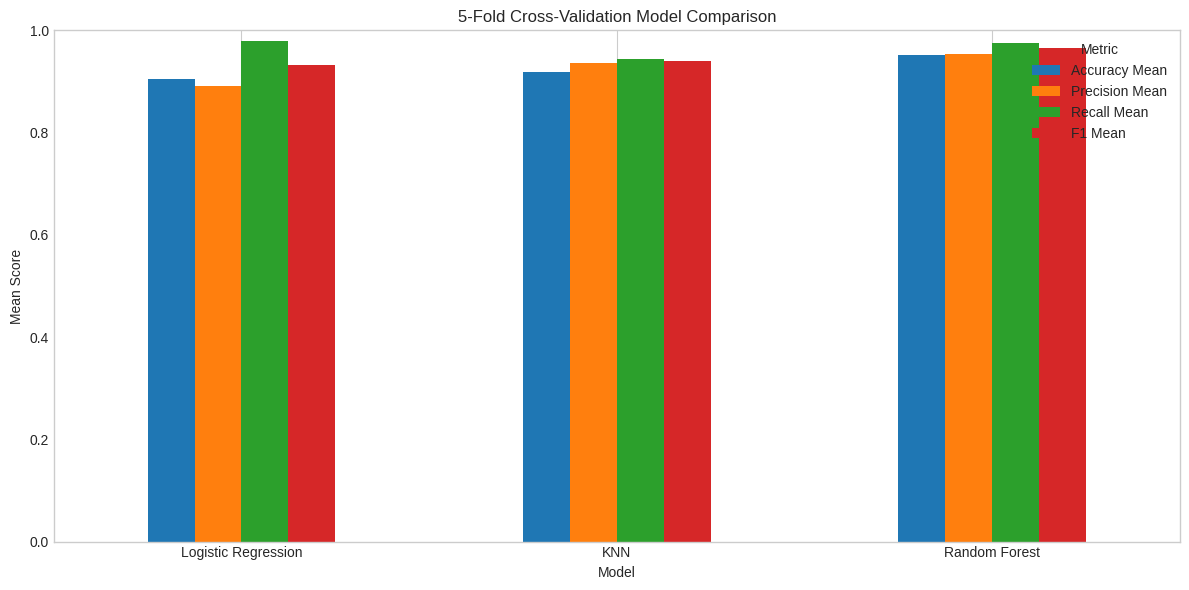

In [39]:
# ─── Model Comparison Plot ───────────────────────────────────────

metrics_to_plot = [
    "Accuracy Mean",
    "Precision Mean",
    "Recall Mean",
    "F1 Mean"
]

plot_cv = cv_summary_df.set_index("Model")[metrics_to_plot]

plot_cv.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("5-Fold Cross-Validation Model Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

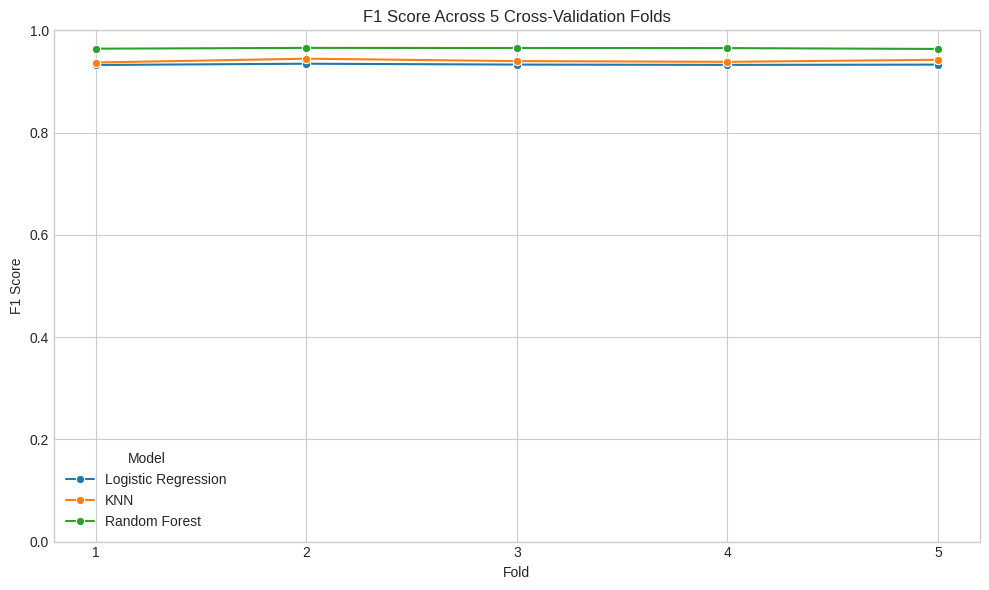

In [40]:
# ─── F1 Score Across Cross-Validation Folds ───────────────────────

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=fold_f1_df,
    x="Fold",
    y="F1 Score",
    hue="Model",
    marker="o"
)

plt.title("F1 Score Across 5 Cross-Validation Folds")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
# ─── Model Stability ─────────────────────────────────────────────

stability_df = cv_summary_df[
    [
        "Model",
        "Accuracy Std",
        "Precision Std",
        "Recall Std",
        "F1 Std"
    ]
].copy()

display(
    stability_df.style.format({
        "Accuracy Std": "{:.4f}",
        "Precision Std": "{:.4f}",
        "Recall Std": "{:.4f}",
        "F1 Std": "{:.4f}"
    })
)

,Model,Accuracy Std,Precision Std,Recall Std,F1 Std
0,Logistic Regression,0.0013,0.0012,0.0007,0.0009
1,KNN,0.0035,0.0011,0.0049,0.0027
2,Random Forest,0.0011,0.0006,0.0012,0.0008


### Interpretation

Three classification models, Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest, were evaluated using stratified 5-fold cross-validation.

Stratified cross-validation was used to maintain a similar proportion of normal and attack traffic in each fold. Standardization was included inside the Logistic Regression and KNN pipelines so that scaling parameters were learned independently within each training fold, reducing the risk of data leakage.

The cross-validation results report the mean and standard deviation of accuracy, precision, recall, and F1-score across the five folds. The mean scores represent the average predictive performance, while the standard deviations provide information about the consistency of each model across different subsets of the training data.

The F1-score is particularly useful for comparing the models because it balances precision and recall. Recall is also important in the context of cyber attack detection because it measures how many actual attack records are correctly identified.

The model comparison provides evidence about both predictive performance and stability. The final model selection should consider the relevant evaluation metrics and the consistency of performance across folds rather than relying on a single train-validation split.


### Model selected based on 5-Fold Cross-Validation

**Random Forest**

Random Forest achieved the highest mean F1-score among the three evaluated models, with a mean F1-score of **0.9648** and a standard deviation of **0.0008** across the five folds. The result indicates strong and consistent performance within the training dataset under 5-fold cross-validation.

The held-out testing set was not used in this cross-validation process, so final generalization performance should be reported separately on the testing set if required.


## Part 6: สรุปผลและ Data Story

### 6.1 สรุปผลการวิเคราะห์

* **CLO1 — Linear Algebra:** PCA was applied to standardized numerical network traffic features to reduce dimensionality and analyze the underlying structure of the dataset. The scree plot and cumulative explained variance were used to examine how the variance is distributed across principal components.

* **CLO2 — Statistical Learning:** The exploratory statistical analysis showed that network traffic features have different distributions and relationships with the attack label. Feature scaling was therefore important, particularly for PCA and distance-based models such as KNN. The KNN bias-variance analysis also demonstrated how changing the number of neighbors affects model complexity and validation performance.

* **CLO3 — Model Building:** Logistic Regression and KNN were trained using an 80/20 stratified train-validation split. Logistic Regression achieved an accuracy of approximately 89.85% and an F1-score of 0.9293, while KNN achieved an accuracy of approximately 92.70% and an F1-score of 0.9472 on the validation set.

* **CLO4 — Model Selection:** Stratified 5-fold cross-validation was used to compare Logistic Regression, KNN, and Random Forest. The mean F1-scores were 0.9331, 0.9404, and 0.9648 respectively. The relatively small standard deviations across folds indicate consistent performance across different subsets of the training data.

* **Overall Data Story:** The analysis demonstrates that the UNSW-NB15 network traffic features contain useful information for distinguishing normal traffic from cyber attacks. The progression from EDA and PCA to statistical analysis, model building, and cross-validation provides a complete machine learning workflow for cyber attack detection.

### 6.2 Limitations

* The analysis used the prepared UNSW-NB15 training dataset rather than the complete original raw dataset, so the results may not represent every possible type of real-world network traffic.
* The project focused on binary classification using the `label` variable, distinguishing normal traffic from attack traffic. The different attack categories in `attack_cat` were not modeled as a multiclass classification problem.
* Only numerical features were used for the main machine learning models. Categorical information was therefore not directly incorporated into the models.
* The models were evaluated using a fixed set of hyperparameters. More extensive hyperparameter tuning could potentially improve model performance.
* The project used standard classification metrics such as accuracy, precision, recall, and F1-score. Additional metrics such as ROC-AUC, PR-AUC, and computational cost could provide a more comprehensive evaluation.
* The final testing dataset was kept separate from the training and cross-validation process. Therefore, the cross-validation results describe performance on the training dataset rather than final generalization performance on the unseen testing set.

### 6.3 ขั้นตอนต่อไป (Future Work)

If more time were available, the project could be extended in several directions:

1. Perform systematic hyperparameter tuning using Grid Search or Randomized Search.
2. Evaluate the selected model on the held-out UNSW-NB15 testing dataset.
3. Compare additional classification algorithms such as XGBoost, SVM, or Gradient Boosting.
4. Investigate multiclass classification using the `attack_cat` variable to identify specific types of cyber attacks.
5. Apply additional feature selection techniques to identify the most informative network traffic features.
6. Evaluate ROC-AUC and Precision-Recall curves in addition to the current classification metrics.
7. Investigate model interpretability techniques such as feature importance or SHAP to understand which network characteristics contribute most to attack detection.

### 6.4 Connection กับ Topics ในวิชา

This project connects several concepts from the course to a real-world cybersecurity machine learning problem:

* **Exploratory Data Analysis:** Descriptive statistics, distributions, and correlation analysis were used to understand the dataset before modeling.
* **Linear Algebra:** Standardization and Principal Component Analysis (PCA) were used to transform and analyze the feature space. PCA relies on concepts such as eigenvectors, eigenvalues, and matrix decomposition.
* **Statistical Learning:** The project examined feature distributions, relationships between variables, and the bias-variance trade-off using KNN with different values of `k`.
* **Machine Learning:** Logistic Regression, KNN, and Random Forest were implemented as classification models.
* **Model Evaluation:** Accuracy, precision, recall, F1-score, and confusion matrices were used to evaluate classification performance.
* **Cross-Validation:** Stratified 5-fold cross-validation was used to obtain more reliable estimates of model performance and compare models across multiple data splits.
* **Data Leakage Prevention:** Feature scaling was performed within appropriate training or cross-validation pipelines so that information from validation folds was not used when fitting the preprocessing step.

Overall, the project applies the mathematical, statistical, and machine learning concepts covered in the course to a practical problem in cybersecurity: detecting malicious network traffic.

---

**Acknowledgements:**
This project uses the UNSW-NB15 dataset for cybersecurity network traffic analysis. The analysis was implemented using Python and common machine learning and data analysis libraries, including Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn. Google Colab was used as the development environment. Dataset source: UNSW-NB15 Version 5 distributed through Kaggle (dataset page linked in the project header).
